# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [24]:
#Eerst importeren we de data
data= np.loadtxt(r'C:\TUDelftProgrameren\thermolab\Figures\tempmetingen.csv',delimiter=';', skiprows=1)

#data sorteren
tijd=data[:,0]
temp=data[:,1]

dT= temp-temp[0]
#andere gegevens uit onderzoek
m_maatbeker=0.8208 #kg #massa van maatbeker
m_water_maatbeker_b= 1.2929 #kg #massa van maatbeker en water aan het begin
m_water_maatbeker_e= 1.2749 #kg #massa van maatbeker en water aan einde

m_water_b= m_water_maatbeker_b-m_maatbeker #kg #massa water begin
m_water_e=m_water_maatbeker_e-m_maatbeker #kg #massa water eind

#Waardes die wij gaan gebruiken
c_w=4186 #J/(kg K) #soortelijke warmte water


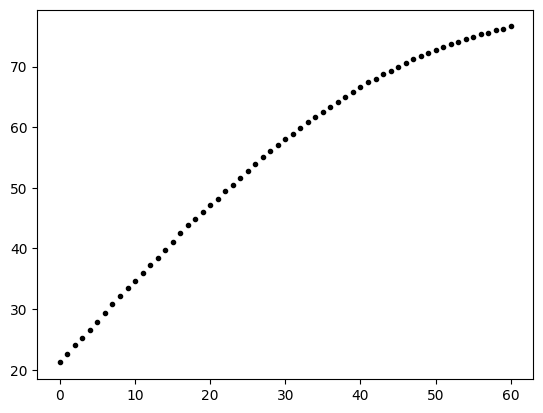

De gefitte P is gelijk aan [2687.64641595] +/- [[8.05736142]] J/min


In [30]:
#Om een verwachtte trendlijn te maken hebben wij het vermogen P nodig
#Deze kun je vinden door het analyseren van de gegevens
#Aan het begin is de kans groter dat alle warmte in het water gaat zitten (nog weinig verdamping en afkoeling)

#plot maken van basis gegevens
plt.figure()
plt.plot(tijd, temp, 'k.')
plt.show()

#in de eerste 10 minuten is dT lineair met de tijd. Deze gaan we gebruiken om P te bepalen

#functie definieren
def dTemp(t,P):
    return P*t/(m_water_b*c_w) #We gebruiken de beginmassa van water want waarschijnlijk heel weinig verdamping

#fit maken voor eerste 10 waardes
P, pcov = curve_fit(dTemp, tijd[:11], dT[:11])

#presenteren P #BELANGRIJK: DIT IS VERMOGEN PER MINUUT
print('De gefitte P is gelijk aan', P,'+/-', np.sqrt(pcov),'J/min')

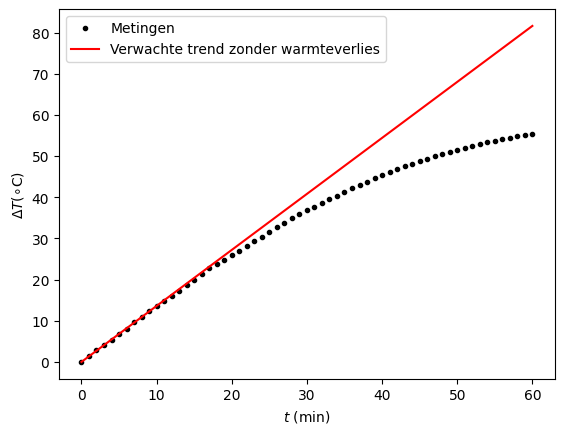

In [39]:
#Oke nu kunnen we een trendlijn maken

t_trend=np.linspace(min(tijd), max(tijd), 600) #minuten
dT_trend= dTemp(t_trend, P)

plt.figure()
plt.plot(tijd, dT, 'k.', label='Metingen')
plt.plot(t_trend, dT_trend, 'r-', label='Verwachte trend zonder warmteverlies')
plt.xlabel('$t$ (min)')
plt.ylabel(r'$\Delta T$($\circ$C)')
plt.legend()
plt.show()

Om te kijken naar hoeveel energie er in de verdamping zit moet je kijken hoeveel enthalpy water heeft bij het verdampen. In de thermodynamica tabellen zie je bij 1 bar (aardse druk) dat er een evaporating enthalpy is van 2258.0 kJ/kg.Hiermee kunnen we kijken hoeveel energie er in het water en de damp zit.

De warmte die in het normale water zit bereken je met de soortelijke warmte van water, de massa en Temperatuur: Q=dT*c*m 
massa op het einde = 0.4541 kg. dT= 55.4 K (of graden Celsius) en c_w=4186 J/(kg K) 
Na rekenen kom je op 105 307 J

De energie die in de damp zit is gelijk aan m*2285e3. De massa is 1.2929-1.2749=0.018 kg.
Na rekenen kom je op 41 130 J. 

De totale energie van water en damp is 105307 + 41130= 146 437 J

Er is in totaal 60 minuten met een vermogen van 2687.6 J/min warmte toegevoegd. 
Dat geeft in totaal 161 256 J. 

Hoewel we nu met damp en vloeibaar los berekenen al dichter bij de totale energie zitten is er nog steeds een gat van ongeveer 15 kJ. Dit verschil kan om meerdere komen. Er gaat natuurlijk ook energie naar de lucht want er zat geen deksel op de maatbeker en ook de maatbeker zelf warmt op. Bij een tijdsduur van een uur gaan deze effecten al een grotere rol spelen. 

In toekomstig onderzoek kun je hier dus rekening meehouden bij het berekenen. Mogelijk zou je de maatbeker in een klein hok kunnen doen zodat de warmte die naar de lucht gaat niet meteen zich verspreidt in een grote kamer. Daardoor wordt het temperatuurverschil tussen lucht en water minder groot en is er dus minder warmteverlies aan de lucht. Een ander idee is om het water in een maatbeker te doen die minimaal warmtegeleidt. Ook een deksel zou helpeb

